In [1]:
import sys
from pathlib import Path

# Notebook is in /home/tp/Documents/uni/dsp/notebooks
repo_root = Path.cwd().parent
scripts_dir = repo_root / "scripts"

# Put /scripts first so it wins over notebooks/lg_analogues.py
sys.path.insert(0, str(scripts_dir))

import lg_analogues
import lg_abc
print("lg_analogues from:", lg_analogues.__file__)
print("lg_abc from:", lg_abc.__file__)


lg_analogues from: /home/tp/Documents/uni/dsp/scripts/lg_analogues.py
lg_abc from: /home/tp/Documents/uni/dsp/scripts/lg_abc.py


In [2]:
import os
import illustris_python as il
import numpy as np
import lg_analogues as lg

basePath = os.path.expanduser("~/Documents/uni/dsp/tng300/outputs")
#basePath = os.path.expanduser("~/Documents/repot/dsp-cosmology/tng300/outputs")

snap = 99

# subhalo fields
subhalo_fields = [ 
    "SubhaloPos",       # Spatial position within the periodic box (of the particle with the minium gravitational potential energy). Comoving coordinate. Units: ckpc/h 
    "SubhaloVel",       # Peculiar velocity of the group, computed as the sum of the mass weighted velocities of all particles/cells in this group, of all types. No unit conversion is needed. Units: km/s
    "SubhaloMass",      # Total mass of all member particle/cells which are bound to this Subhalo, of all types. Particle/cells bound to subhaloes of this Subhalo are NOT accounted for. Units: 1e10 Msun/h
    "SubhaloMassType",  # Total mass of all member particle/cells which are bound to this Subhalo, separated by type. Particle/cells bound to subhaloes of this Subhalo are NOT accounted for. Units: 1e10 Msun/h
    "SubhaloSFRinRad",  # Sum of the individual star formation rates of all gas cells in this subhalo, but restricted to cells within the radius of 𝑉𝑚𝑎𝑥. Units Msun/yr
    "SubhaloFlag",      # Flag field indicating suitability of this subhalo for certain types of analysis. If zero, this subhalo should generally be excluded, and is not thought to be of cosmological origin.
    "SubhaloGrNr",      # Index into the Group table of the FOF host/parent of this Subhalo. 
    "SubhaloStellarPhotometrics", # Eight bands: U, B, V, K, g, r, i, z. Magnitudes based on the summed-up luminosities of all the stellar particles of the group.
    "SubhaloSFR"        # Sum of the individual star formation rates of all gas cells in this subhalo.
    
]

sub = il.groupcat.loadSubhalos(basePath, snap, fields=subhalo_fields)

## Building a "central + largest satellite" sample (and why)

### What this selection means

We now select **two subhalos per FoF group** (when available):
1. The **central** (primary) subhalo - analogous to MW or M31
2. The **largest satellite by stellar mass** 

This better represents Local Group analogues like:
- MW + LMC (where LMC is the massive satellite)
- M31 + M33 (where M33 is a satellite of M31)

### Why this matters for Local Group analogues

By selecting both central and largest satellite per group, we can:

1. Find pairs like "MW analogue + M31 analogue"
2. Find pairs like "MW analogue + LMC analogue" (from different groups)
3. Better capture the full mass and dynamics of galaxy groups

### Implementation

Uses `lg_analogues.select_central_plus_largest_satellite_by_stellar_mass()` which:
- Loads group catalog to identify centrals and satellites per FoF halo
- For each group, picks the central subhalo
- For each group, picks the most massive satellite (by stellar mass) if it exists
- Filters both by the stellar mass range [mstar_min, mstar_max]
- Returns positions, velocities, masses, and indices

In [2]:
# Load header constants
header_consts = lg.load_header_constants(basePath, snap)
h = header_consts["h"]
box_ckpch = header_consts["box_ckpch"]

# Define stellar mass range
mstar_min = 2e10  # Msun
mstar_max = 5e11  # Msun

# Select central + largest satellite per FoF group
sample = lg.select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=basePath,
    snap=snap,
    h=h,
    mstar_min=mstar_min,
    mstar_max=mstar_max,
)

# Extract arrays from the Sample object
pos_s = sample.pos
vel_s = sample.vel
mstar_s = sample.mstar
mdm_s = sample.mdm
grnr_s = sample.grnr
mtype_s = sample.mtype

# Get photometry and SFR for the selected sample
keep_idx = sample.keep_idx
phot_s = sub["SubhaloStellarPhotometrics"][keep_idx]
sfr_s = sub["SubhaloSFR"][keep_idx]

print("All subhalos:", sub["count"])
print("Selected subhalos (central + largest satellite):", len(keep_idx))
print("h used:", h)
print("Box size (ckpc/h):", box_ckpch)
print("Stellar mass range [Msun]:", mstar_min, "to", mstar_max)

All subhalos: 14485709
Selected subhalos (central + largest satellite): 45392
h used: 0.6774
Box size (ckpc/h): 205000.0
Stellar mass range [Msun]: 20000000000.0 to 500000000000.0


## Stellar mass

Next we to compute stellar mass per central subhalo and keep only objects in a reasonable stellar-mass range. This matters because pair-finding on ~11.5 million centrals will still be heavy, while pair-finding on (say) a few hundred thousand “MW-ish” centrals is manageable.

### What “stellar mass” is in this table

SubhaloMassType is mass by particle type, in units of 1e10 Msun/h. The type mapping is the standard TNG particle-type convention: PartType4 = stars & wind particles, PartType1 = dark matter.

Mstar = SubhaloMassType[:, 4] * 1e10 / h (Msun)

Mdm = SubhaloMassType[:, 1] * 1e10 / h (Msun)

TNG300-1 lists "h" as 0.6774.

### Sanity plot (stellar mass vs DM mass) for filtered centrals

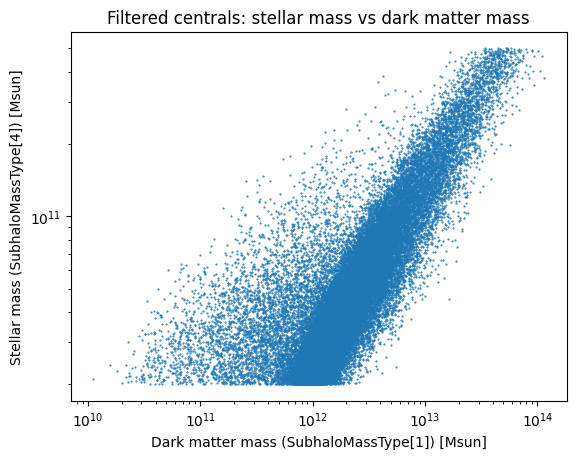

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(mdm_s, mstar_s, ".", markersize=1)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Dark matter mass (SubhaloMassType[1]) [Msun]")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")

plt.title("Filtered centrals: stellar mass vs dark matter mass")
plt.show()


### Prepare for pair-finding (define the distance window)

Key detail: SubhaloPos is in ckpc/h (comoving kpc divided by h).
At snapshot 99, z=0, so comoving = physical length, and the conversion to kpc is:

kpc = (ckpc/h) / h

equivalently, ckpc/h = kpc * h

In [4]:
import numpy as np

# Distance window for pair-finding (in kpc, physical)
r_min_kpc = 500
r_max_kpc = 1000

# Find pairs using the lg_analogues module
pair_set = lg.find_pairs_periodic(
    pos=pos_s,
    vel=vel_s,
    grnr=grnr_s,
    h=h,
    box_ckpch=box_ckpch,
    r_min_kpc=r_min_kpc,
    r_max_kpc=r_max_kpc,
)

# Extract pair indices and kinematics
i = pair_set.i
j = pair_set.j
dist_kpc = pair_set.dist_kpc
v_r = pair_set.v_r
v_t = pair_set.v_t
same_host = pair_set.same_host

# Keep all pairs (same-host + different-host) for isolation filter
print("Pairs found in distance window (all pairs):", len(i))
print(f"  Same-host pairs: {np.sum(same_host)}")
print(f"  Different-host pairs: {np.sum(~same_host)}")

# -observed radial velocity for later use (formula relating radial peculiar velocity and radial observed velocity. We use radial peculiar velocity for eda)
H0 = 100.0 * h                  
v_hubble = H0 * (dist_kpc / 1000.0)
v_r_obs = v_r + v_hubble


print("Separation stats [kpc]: min/median/max =", np.min(dist_kpc), np.median(dist_kpc), np.max(dist_kpc))
print("v_r stats [km/s]: min/median/max =", np.min(v_r), np.median(v_r), np.max(v_r))
print("v_t stats [km/s]: min/median/max =", np.min(v_t), np.median(v_t), np.max(v_t))

# Formula for total peculiar velocity
v_total = np.sqrt(v_r**2 + v_t**2)

# Apply isolation filter

# First, prepare the top-3 mass lookup for each group
mstar_all = sub["SubhaloMassType"][:, 4].astype(np.float64) * 1e10 / h
grnr_all = sub["SubhaloGrNr"].astype(np.int64)
good_all = (sub["SubhaloFlag"] == 1) & (grnr_all >= 0) & (mstar_all > 0)

# FoF groups that appear in at least one pair member
groups_in_pairs = np.unique(np.concatenate([grnr_s[i], grnr_s[j]]).astype(np.int64))

# Candidate subhalos for those groups only
cand = good_all & np.isin(grnr_all, groups_in_pairs)
cand_idx = np.nonzero(cand)[0]
cand_gr = grnr_all[cand_idx]
cand_m = mstar_all[cand_idx]

# Sort by group id, then by stellar mass descending
order = np.lexsort((-cand_m, cand_gr))
cand_idx = cand_idx[order]
cand_gr = cand_gr[order]
cand_m = cand_m[order]

# Find group boundaries in this sorted list
starts = np.flatnonzero(np.r_[True, cand_gr[1:] != cand_gr[:-1]])
ends = np.r_[starts[1:], cand_gr.size]

# Store top-3 (mass, index) per group in dicts
top_idx = {}
top_m = {}

for s, e in zip(starts, ends):
    g = cand_gr[s]
    take = min(3, e - s)
    top_idx[g] = cand_idx[s:s+take]
    top_m[g] = cand_m[s:s+take]

# Apply isolation filter
cs1_global_idx = sample.keep_idx  # global subhalo index for each sample row
x = 2.0  # reject if there exists a third subhalo >= x times the larger member
keep_iso = np.ones(i.size, dtype=bool)

for k in range(i.size):
    a = i[k]
    b = j[k]
    
    ga = int(grnr_s[a])
    gb = int(grnr_s[b])
    
    ma = mstar_s[a]
    mb = mstar_s[b]
    scale = max(ma, mb)
    
    a_global = int(cs1_global_idx[a])
    b_global = int(cs1_global_idx[b])
    
    def violates(g):
        if g not in top_idx:
            return False
        idxs = top_idx[g]
        ms = top_m[g]
        for idx_val, m_val in zip(idxs, ms):
            idx_val = int(idx_val)
            if (idx_val != a_global) and (idx_val != b_global):
                return m_val >= x * scale
        return False
    
    # Same-host pairs: check that one group
    # Different-host pairs: check both groups
    if ga == gb:
        if violates(ga):
            keep_iso[k] = False
    else:
        if violates(ga) or violates(gb):
            keep_iso[k] = False

# Apply isolation filter
i = i[keep_iso]
j = j[keep_iso]
dist_kpc = dist_kpc[keep_iso]
v_r = v_r[keep_iso]
v_t = v_t[keep_iso]
v_total = v_total[keep_iso]

same_host = same_host[keep_iso]  # Filter same_host array too

print(f"\nPairs after isolation filter: {len(i)}")
print(f"Removed by isolation: {np.sum(~keep_iso)}")
print(f"Separation stats [kpc]: min/median/max = {np.min(dist_kpc):.1f}, {np.median(dist_kpc):.1f}, {np.max(dist_kpc):.1f}")
print(f"v_r stats [km/s]: min/median/max = {np.min(v_r):.1f}, {np.median(v_r):.1f}, {np.max(v_r):.1f}")
print(f"v_t stats [km/s]: min/median/max = {np.min(v_t):.1f}, {np.median(v_t):.1f}, {np.max(v_t):.1f}")

# Apply velocity cuts
velocity_cut = (
    (v_r < 0) &              # approaching
    (v_r > -400) &           
    (v_t < 300) &            
    (v_total < 500)          
)

i_final = i[velocity_cut]
j_final = j[velocity_cut]
v_r_final = v_r[velocity_cut]
v_t_final = v_t[velocity_cut]
dist_kpc_final = dist_kpc[velocity_cut]

same_host_final = same_host[velocity_cut]  # Track final same-host status

print(f"\nPairs after velocity filtering: {len(i_final)}")
print(f"  → Rejected {len(i) - len(i_final)} pairs ({100*(len(i)-len(i_final))/len(i):.1f}%)")
print(f"v_r [km/s]: min/median/max = {np.min(v_r_final):.1f}, {np.median(v_r_final):.1f}, {np.max(v_r_final):.1f}")
print(f"v_t [km/s]: min/median/max = {np.min(v_t_final):.1f}, {np.median(v_t_final):.1f}, {np.max(v_t_final):.1f}")
print(f"  Same-host pairs: {np.sum(same_host_final)}")
print(f"  Different-host pairs: {np.sum(~same_host_final)}")


Pairs found in distance window (all pairs): 2655
  Same-host pairs: 2084
  Different-host pairs: 571
Separation stats [kpc]: min/median/max = 500.37125 740.6079 999.99115
v_r stats [km/s]: min/median/max = -1282.8807 -123.82173 748.37384
v_t stats [km/s]: min/median/max = 3.0065033 155.03734 1626.0802

Pairs after isolation filter: 2620
Removed by isolation: 35
Separation stats [kpc]: min/median/max = 500.4, 738.2, 1000.0
v_r stats [km/s]: min/median/max = -1282.9, -123.9, 748.4
v_t stats [km/s]: min/median/max = 3.0, 153.8, 1626.1

Pairs after velocity filtering: 1768
  → Rejected 852 pairs (32.5%)
v_r [km/s]: min/median/max = -396.6, -147.9, -0.1
v_t [km/s]: min/median/max = 3.0, 123.2, 299.4
  Same-host pairs: 1384
  Different-host pairs: 384


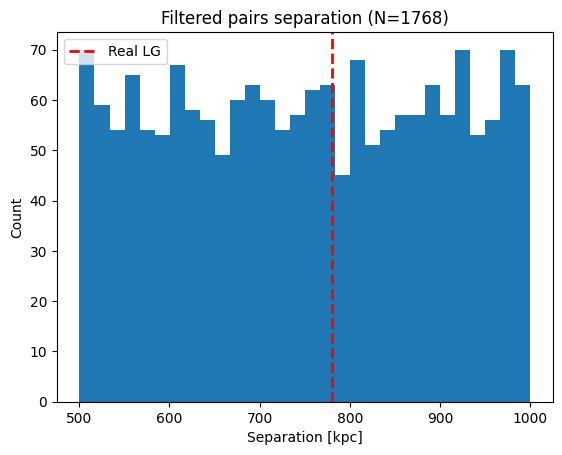

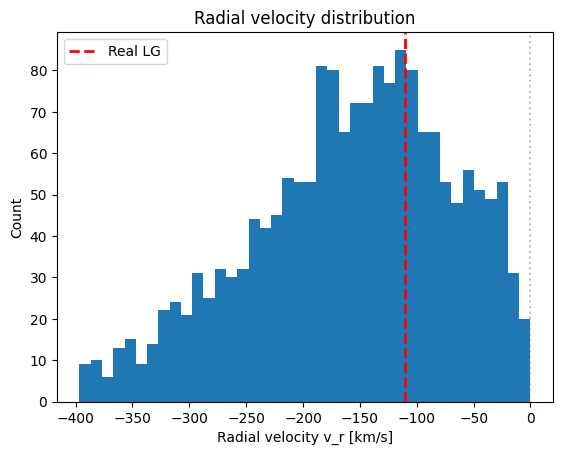

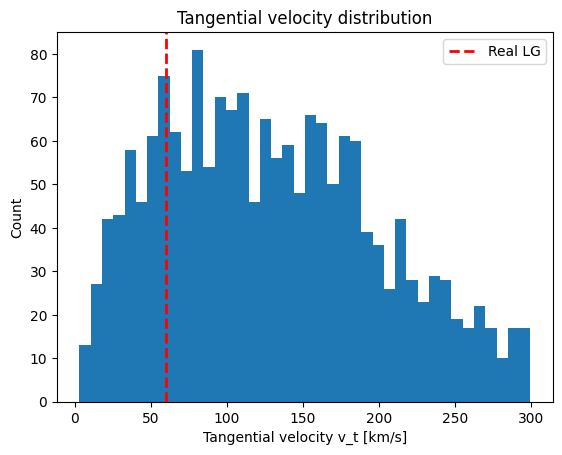

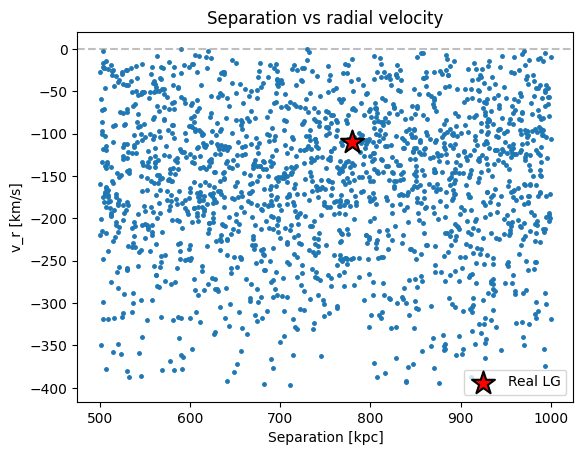

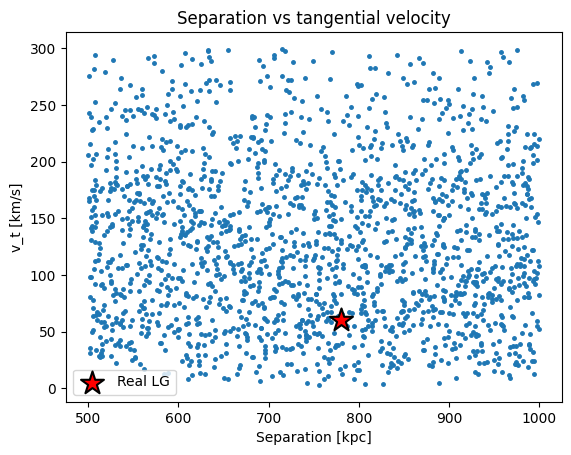

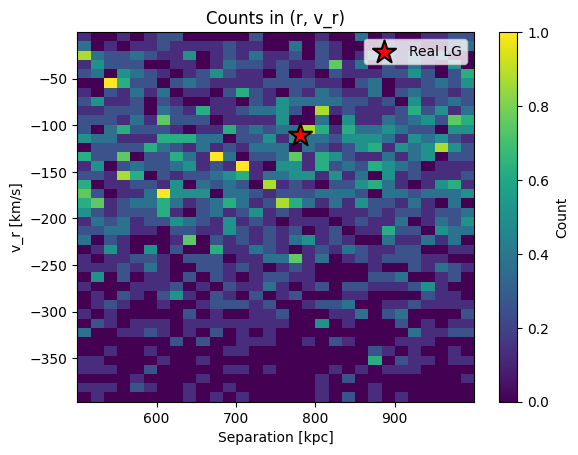

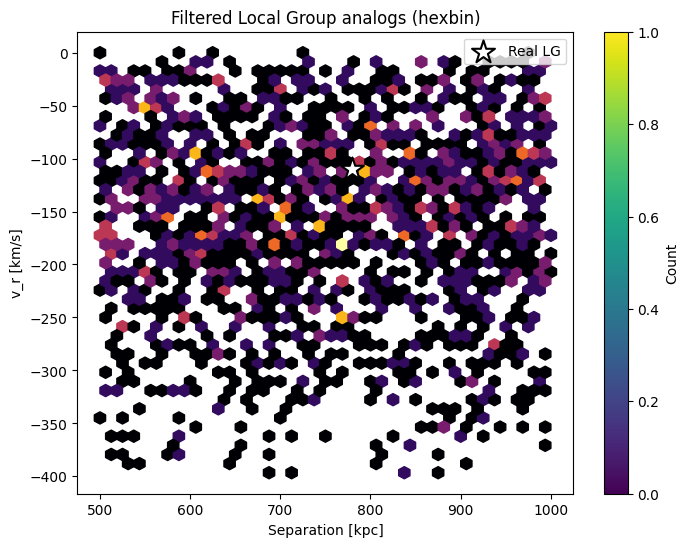


Filtered pairs: 1768
Separation range: 500.4 - 1000.0 kpc
v_r range: -396.6 - -0.1 km/s
v_t range: 3.0 - 299.4 km/s
Approaching pairs: 1768 / 1768


In [5]:
import matplotlib.pyplot as plt

# Real Local Group values checked online
LG_sep = 780   # kpc
LG_vr = -110   # km/s
LG_vt = 60     # km/s

# Separation histogram
plt.figure()
plt.hist(dist_kpc_final, bins=30)
plt.axvline(LG_sep, color='red', linestyle='--', linewidth=2, label='Real LG')
plt.xlabel("Separation [kpc]")
plt.ylabel("Count")
plt.title(f"Filtered pairs separation (N={len(dist_kpc_final)})")
plt.legend()
plt.show()

# Radial velocity histogram
plt.figure()
plt.hist(v_r_final, bins=40)
plt.axvline(LG_vr, color='red', linestyle='--', linewidth=2, label='Real LG')
plt.axvline(0, color='gray', linestyle=':', alpha=0.5)
plt.xlabel("Radial velocity v_r [km/s]")
plt.ylabel("Count")
plt.title("Radial velocity distribution")
plt.legend()
plt.show()

# Tangential velocity histogram
plt.figure()
plt.hist(v_t_final, bins=40)
plt.axvline(LG_vt, color='red', linestyle='--', linewidth=2, label='Real LG')
plt.xlabel("Tangential velocity v_t [km/s]")
plt.ylabel("Count")
plt.title("Tangential velocity distribution")
plt.legend()
plt.show()

# Separation vs v_r scatter
plt.figure()
plt.plot(dist_kpc_final, v_r_final, ".", markersize=5)
plt.scatter(LG_sep, LG_vr, marker='*', s=300, color='red', edgecolor='black', linewidth=1.5, label='Real LG', zorder=10)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Separation [kpc]")
plt.ylabel("v_r [km/s]")
plt.title("Separation vs radial velocity")
plt.legend()
plt.show()

# Separation vs v_t scatter
plt.figure()
plt.plot(dist_kpc_final, v_t_final, ".", markersize=5)
plt.scatter(LG_sep, LG_vt, marker='*', s=300, color='red', edgecolor='black', linewidth=1.5, label='Real LG', zorder=10)
plt.xlabel("Separation [kpc]")
plt.ylabel("v_t [km/s]")
plt.title("Separation vs tangential velocity")
plt.legend()
plt.show()

# 2D histogram (r, v_r)
plt.figure()
plt.hist2d(dist_kpc_final, v_r_final, bins=[30, 40])
plt.scatter(LG_sep, LG_vr, marker='*', s=300, color='red', edgecolor='black', linewidth=1.5, label='Real LG', zorder=10)
plt.xlabel("Separation [kpc]")
plt.ylabel("v_r [km/s]")
plt.title("Counts in (r, v_r)")
plt.colorbar(label="Count")
plt.legend()
plt.show()

# Heatmap
plt.figure(figsize=(8, 6))
plt.hexbin(dist_kpc_final, v_r_final, gridsize=40, cmap='inferno', mincnt=1)
plt.scatter(LG_sep, LG_vr, marker='*', s=300, color='white', edgecolor='black', linewidth=1.5, label='Real LG', zorder=10)
plt.colorbar(label='Count')
plt.xlabel("Separation [kpc]")
plt.ylabel("v_r [km/s]")
plt.title("Filtered Local Group analogs (hexbin)")
plt.legend()
plt.show()

# Print summary
print(f"\nFiltered pairs: {len(dist_kpc_final)}")
print(f"Separation range: {dist_kpc_final.min():.1f} - {dist_kpc_final.max():.1f} kpc")
print(f"v_r range: {v_r_final.min():.1f} - {v_r_final.max():.1f} km/s")
print(f"v_t range: {v_t_final.min():.1f} - {v_t_final.max():.1f} km/s")
print(f"Approaching pairs: {(v_r_final < 0).sum()} / {len(v_r_final)}")

**Going to calculate M1/M2 ratio and ensure it stays above 1 for more plots. Plotting stellar mass and Dark matter mass ratios and other quantities against mass ratios**

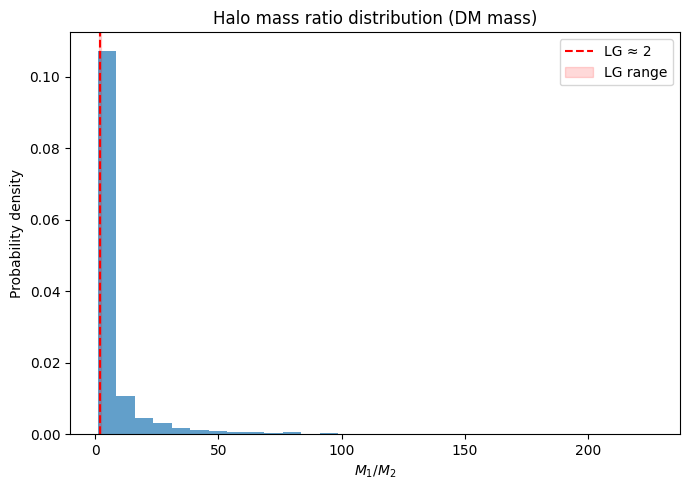

Number of final pairs: 1768
Median M1/M2: 3.167585627072287
16–84 percentile: [ 1.50886472 10.69781218]
LG-like fraction: 0.2341628959276018


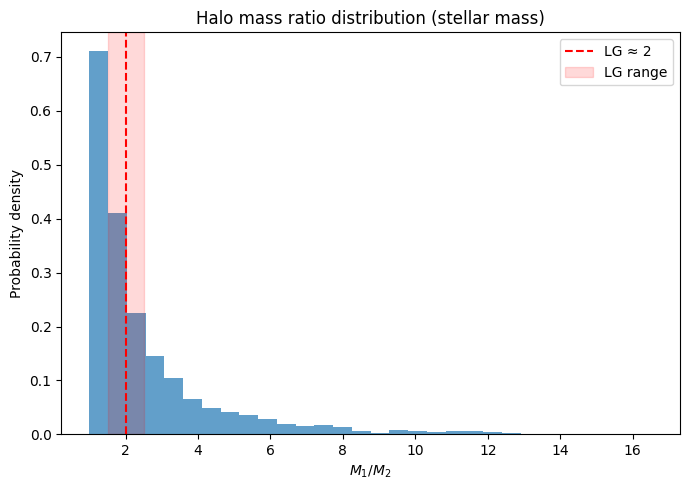

In [6]:
# Halo Dark Matter masses
Mi = mdm_s[i_final]
Mj = mdm_s[j_final]

# Enforce M1 >= M2
M1 = np.maximum(Mi, Mj)
M2 = np.minimum(Mi, Mj)

mass_ratio_dm = M1 / M2

plt.figure(figsize=(7, 5))

plt.hist(
    mass_ratio_dm,
    bins=30,
    density=True,
    alpha=0.7
)

# Local Group reference
plt.axvline(2.0, color="r", linestyle="--", label="LG ≈ 2")
plt.axvspan(1.5, 2.5, color="r", alpha=0.15, label="LG range")

plt.xlabel(r"$M_1 / M_2$")
plt.ylabel("Probability density")
plt.title("Halo mass ratio distribution (DM mass)")
plt.legend()
plt.tight_layout()
plt.show()

print("Number of final pairs:", len(mass_ratio_dm))
print("Median M1/M2:", np.median(mass_ratio_dm))
print("16–84 percentile:", np.percentile(mass_ratio_dm, [16, 84]))

lg_like = np.sum((mass_ratio_dm >= 1.5) & (mass_ratio_dm <= 2.5))
print("LG-like fraction:", lg_like / len(mass_ratio_dm))

# Stellar Masses
Mi_star = mstar_s[i_final]
Mj_star = mstar_s[j_final]

M1_star = np.maximum(Mi_star, Mj_star)
M2_star = np.minimum(Mi_star, Mj_star)

mass_ratio_star = M1_star / M2_star

plt.figure(figsize=(7, 5))

plt.hist(
    mass_ratio_star,
    bins=30,
    density=True,
    alpha=0.7
)

# Local Group reference
plt.axvline(2.0, color="r", linestyle="--", label="LG ≈ 2")
plt.axvspan(1.5, 2.5, color="r", alpha=0.15, label="LG range")

plt.xlabel(r"$M_1 / M_2$")
plt.ylabel("Probability density")
plt.title("Halo mass ratio distribution (stellar mass)")
plt.legend()
plt.tight_layout()
plt.show()






### Trying some scatter plots to find some correlations.

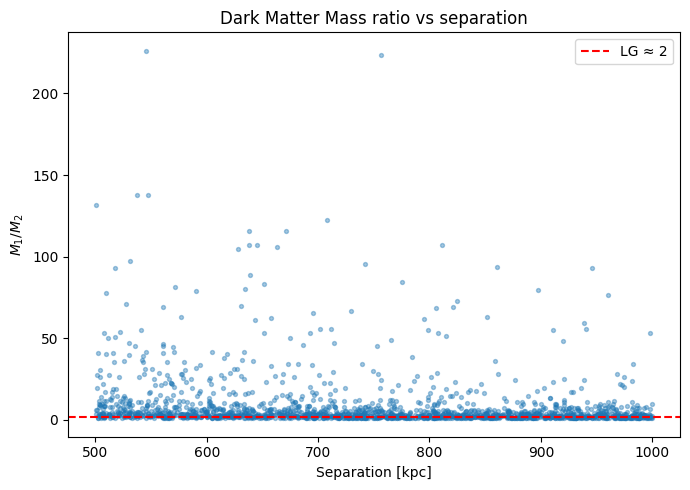

In [7]:
plt.figure(figsize=(7, 5))

plt.scatter(
    dist_kpc_final,
    mass_ratio_dm,
    s=8,
    alpha=0.4
)

plt.axhline(2.0, color="r", linestyle="--", label="LG ≈ 2")

plt.xlabel("Separation [kpc]")
plt.ylabel(r"$M_1 / M_2$")
plt.title("Dark Matter Mass ratio vs separation")
plt.legend()
plt.tight_layout()
plt.show()

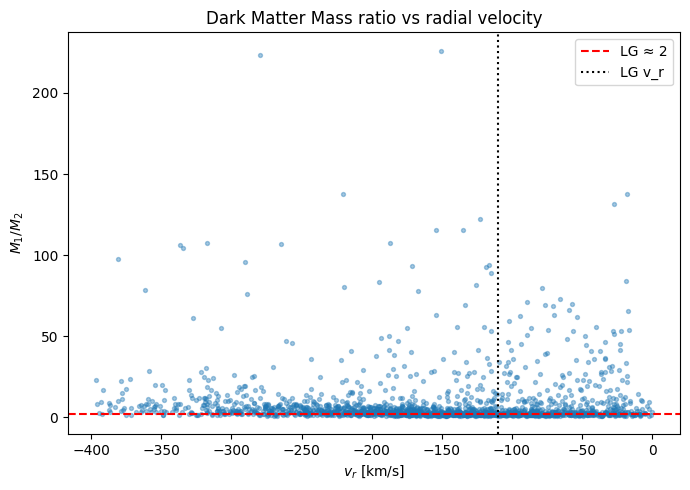

In [8]:
plt.figure(figsize=(7, 5))

plt.scatter(
    v_r_final,
    mass_ratio_dm,
    s=8,
    alpha=0.4
)

plt.axhline(2.0, color="r", linestyle="--", label="LG ≈ 2")
plt.axvline(-110, color="k", linestyle=":", label="LG v_r")

plt.xlabel(r"$v_r$ [km/s]")
plt.ylabel(r"$M_1 / M_2$")
plt.title("Dark Matter Mass ratio vs radial velocity")
plt.legend()
plt.tight_layout()
plt.show()


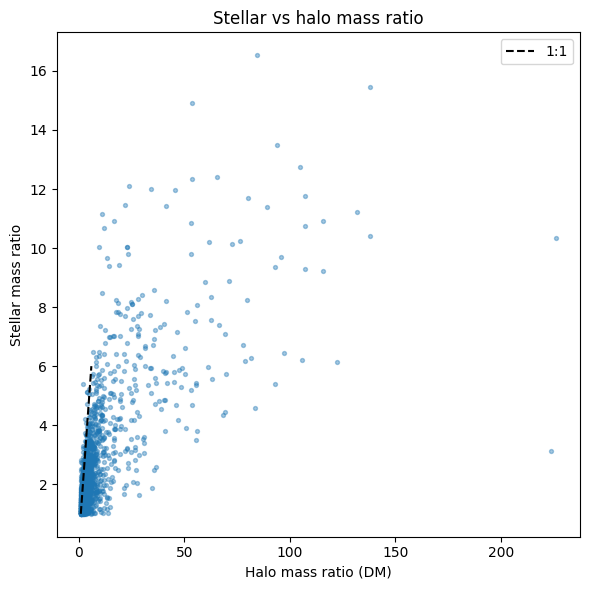

In [9]:
plt.figure(figsize=(6, 6))

plt.scatter(
    mass_ratio_dm,
    mass_ratio_star,
    s=8,
    alpha=0.4
)

plt.plot([1, 6], [1, 6], "k--", label="1:1")

plt.xlabel("Halo mass ratio (DM)")
plt.ylabel("Stellar mass ratio")
plt.title("Stellar vs halo mass ratio")
plt.legend()
plt.tight_layout()
plt.show()


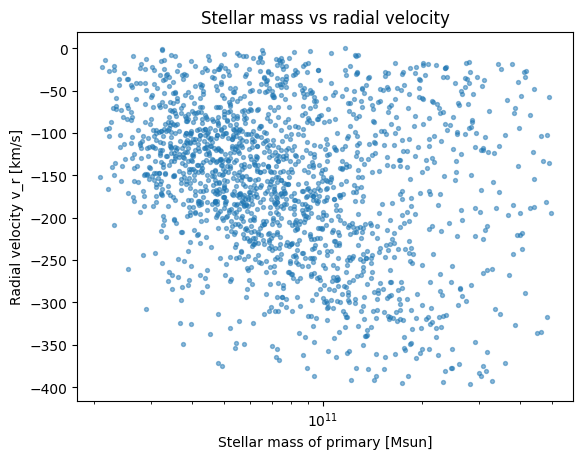

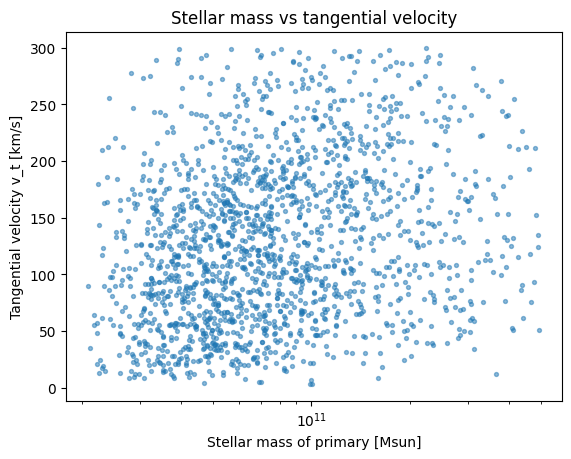

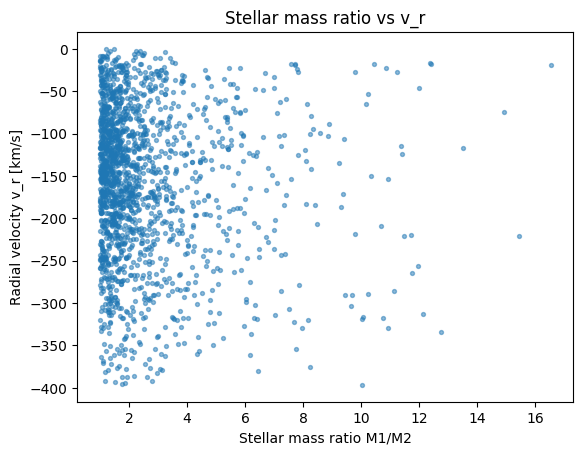

In [10]:
plt.scatter(M1_star, v_r_final, s=8, alpha=0.5)
plt.xscale("log")
plt.xlabel("Stellar mass of primary [Msun]")
plt.ylabel("Radial velocity v_r [km/s]")
plt.title("Stellar mass vs radial velocity")
plt.show()

plt.scatter(M1_star, v_t_final, s=8, alpha=0.5)
plt.xscale("log")
plt.xlabel("Stellar mass of primary [Msun]")
plt.ylabel("Tangential velocity v_t [km/s]")
plt.title("Stellar mass vs tangential velocity")
plt.show()

plt.scatter(mass_ratio_star, v_r_final, s=8, alpha=0.5)
plt.xlabel("Stellar mass ratio M1/M2")
plt.ylabel("Radial velocity v_r [km/s]")
plt.title("Stellar mass ratio vs v_r")
plt.show()


 Does not seem to be any correlation. Everything just seems scattered randomly. Now going to try histograms.

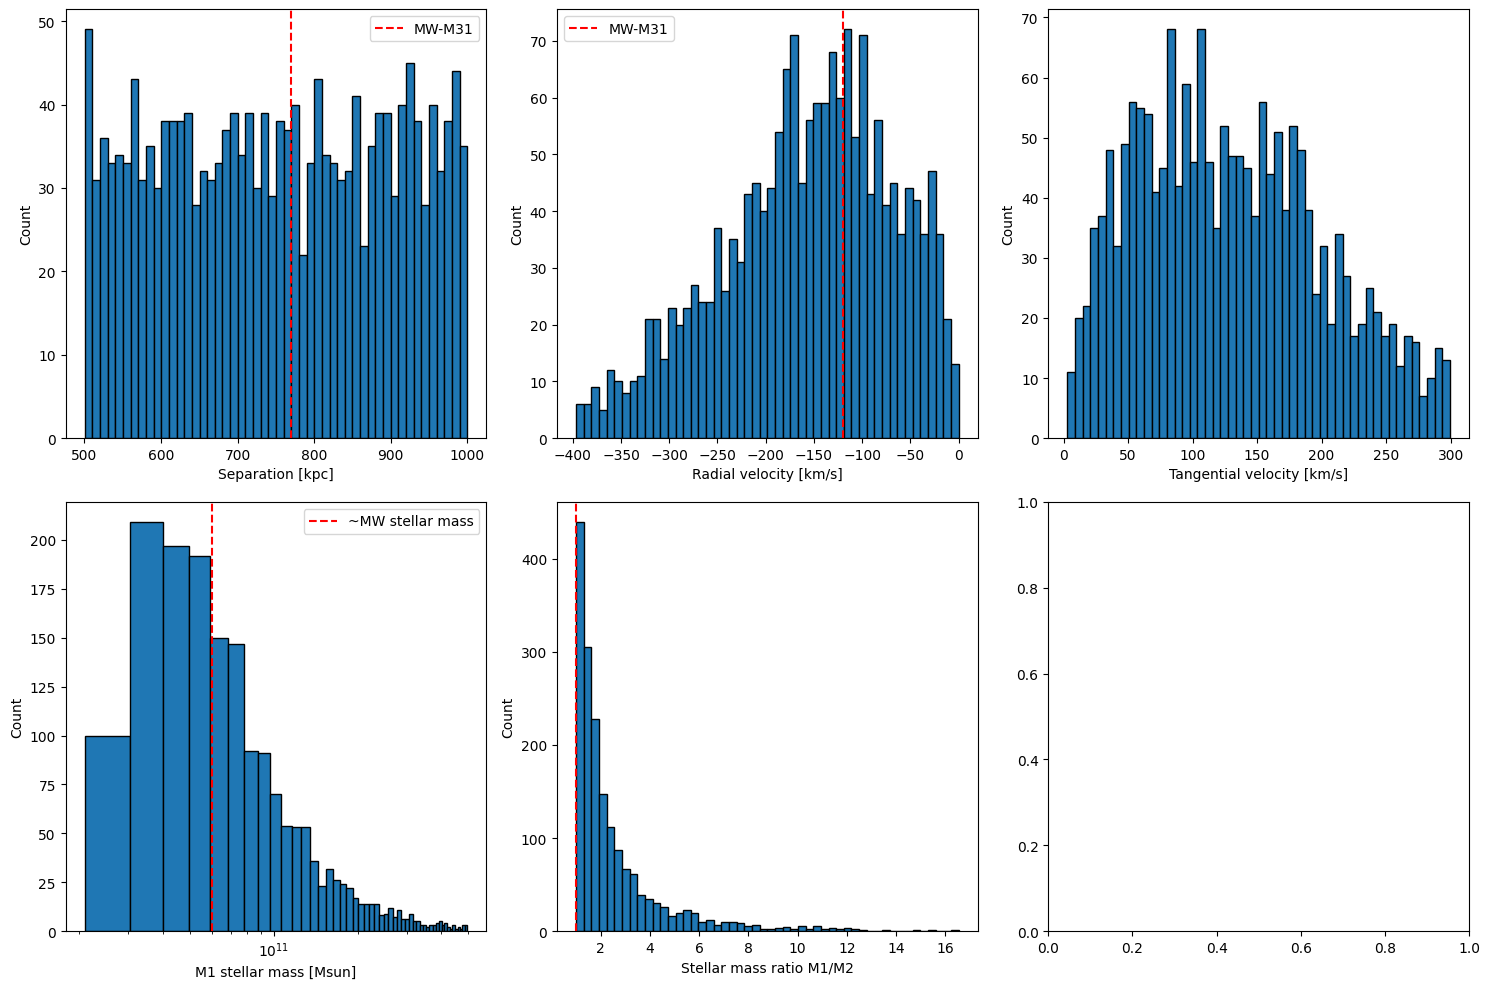

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Separations
axes[0,0].hist(dist_kpc_final, bins=50, edgecolor='black')
axes[0,0].axvline(770, color='red', linestyle='--', label='MW-M31')
axes[0,0].set_xlabel('Separation [kpc]')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Radial velocity
axes[0,1].hist(v_r_final, bins=50, edgecolor='black')
axes[0,1].axvline(-120, color='red', linestyle='--', label='MW-M31')
axes[0,1].set_xlabel('Radial velocity [km/s]')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Tangential velocity
axes[0,2].hist(v_t_final, bins=50, edgecolor='black')
axes[0,2].set_xlabel('Tangential velocity [km/s]')
axes[0,2].set_ylabel('Count')

# Stellar mass of primaries
axes[1,0].hist(M1_star, bins=50, edgecolor='black')
axes[1,0].axvline(6e10, color='red', linestyle='--', label='~MW stellar mass')
axes[1,0].set_xlabel('M1 stellar mass [Msun]')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xscale('log')
axes[1,0].legend()

# Mass ratio
axes[1,1].hist(mass_ratio_star, bins=50, edgecolor='black')
axes[1,1].axvline(1, color='red', linestyle='--', label='Equal mass')
axes[1,1].set_xlabel('Stellar mass ratio M1/M2')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Total pairs: 1768
LG-like pairs (±1σ observables): 287
Percentage: 16.2%


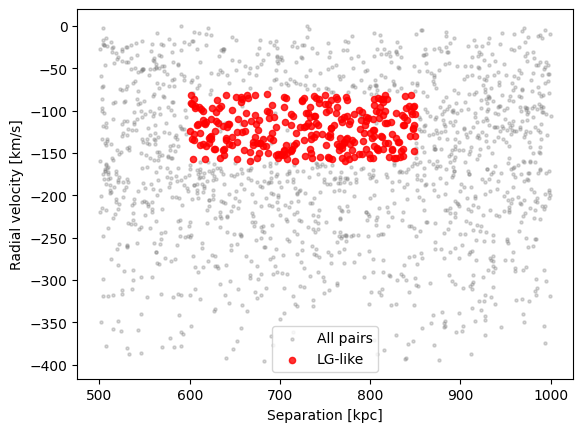

In [12]:
# Define close to local group. Tight constraints for visualization
lg_like = (
    (dist_kpc_final > 600) & (dist_kpc_final < 850) &  # around 780 kpc
    (v_r_final < -80) & (v_r_final > -160) &           # around -120 km/s
    (mass_ratio_star > 1.0) & (mass_ratio_star < 5)    # roughly 1
)

print(f"Total pairs: {len(dist_kpc_final)}")
print(f"LG-like pairs (±1σ observables): {np.sum(lg_like)}")
print(f"Percentage: {100 * np.sum(lg_like) / len(dist_kpc_final):.1f}%")

# Plot these specially
plt.scatter(dist_kpc_final[~lg_like], v_r_final[~lg_like], 
            s=5, alpha=0.3, c='gray', label='All pairs')
plt.scatter(dist_kpc_final[lg_like], v_r_final[lg_like], 
            s=20, alpha=0.8, c='red', label='LG-like')
plt.xlabel('Separation [kpc]')
plt.ylabel('Radial velocity [km/s]')
plt.legend()
plt.show()

## *Photometrics relation with specific star formation rate*

As discussed in the last meeting SubhaloStellarPhotometrics is a logarithmic variable. Difference corresponds to ratio and sum to the product between two values. Keeping this in mind we take the difference to find the color of the pair which is basically the ratio (logarithmic difference).


Color is defined as $$g-r = m_g-m_r$$
And we know from documentation that the indices are U, B, V, K, g, r, i, z. So g and r represent the 4th and the 5th index.

In [13]:
g_r_1 = phot_s[i_final, 4] - phot_s[i_final, 5]
g_r_2 = phot_s[j_final, 4] - phot_s[j_final, 5]


Now we relate to specific star formation rate.

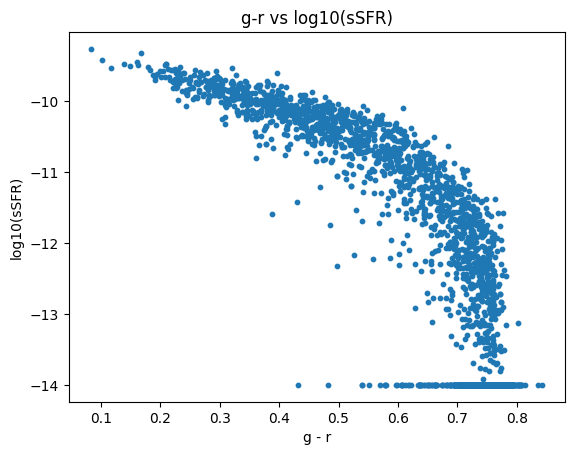

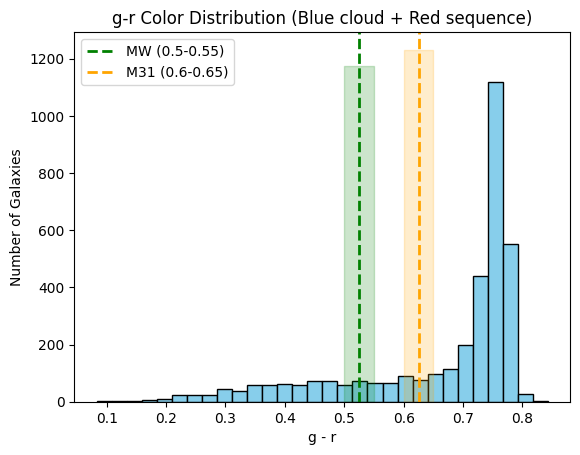

Number of pairs with both members blue: 167 / 1768
Fraction of morphologically LG-like pairs: 0.09


In [14]:
ssfr1 = sfr_s[i_final] / Mi_star
ssfr2 = sfr_s[j_final] / Mj_star
ssfr1 = np.where(ssfr1 > 0, ssfr1, 1e-14) # was getting divide by zero error
ssfr2 = np.where(ssfr2 > 0, ssfr2, 1e-14) # 1e-14 physically reasonable for quenched system

log_ssfr1 = np.log10(ssfr1)
log_ssfr2 = np.log10(ssfr2)

g_r_all = np.concatenate([g_r_1, g_r_2])
log_ssfr_all = np.concatenate([log_ssfr1, log_ssfr2])

plt.scatter(g_r_all, log_ssfr_all, s=10)
plt.xlabel("g - r")
plt.ylabel("log10(sSFR)")
plt.title("g-r vs log10(sSFR)")
plt.show()

plt.figure()
plt.hist(g_r_all, bins=30, color='skyblue', edgecolor='k')
plt.xlabel("g - r")
plt.ylabel("Number of Galaxies")
plt.title("g-r Color Distribution (Blue cloud + Red sequence)")
plt.axvline(0.525, color='green', linestyle='--', linewidth=2, label='MW (0.5-0.55)')
plt.axvline(0.625, color='orange', linestyle='--', linewidth=2, label='M31 (0.6-0.65)')
plt.fill_betweenx([0, plt.gca().get_ylim()[1]], 0.5, 0.55, color='green', alpha=0.2)
plt.fill_betweenx([0, plt.gca().get_ylim()[1]], 0.6, 0.65, color='orange', alpha=0.2)
plt.legend()
plt.show()

# Boolean arrays: True = blue (spiral-like) False = red (elliptical-like)
blue_1 = g_r_1 < 0.65
blue_2 = g_r_2 < 0.65

# Count pairs where both are blue
both_blue = np.logical_and(blue_1, blue_2)
num_both_blue = np.sum(both_blue)
total_pairs = len(i_final)

fraction_both_blue = num_both_blue / total_pairs

print(f"Number of pairs with both members blue: {num_both_blue} / {total_pairs}")
print(f"Fraction of morphologically LG-like pairs: {fraction_both_blue:.2f}")



Could possibly remove the points right at the bottom for a smoother plot

Now lets take a look at some luminosity plots and analysis.

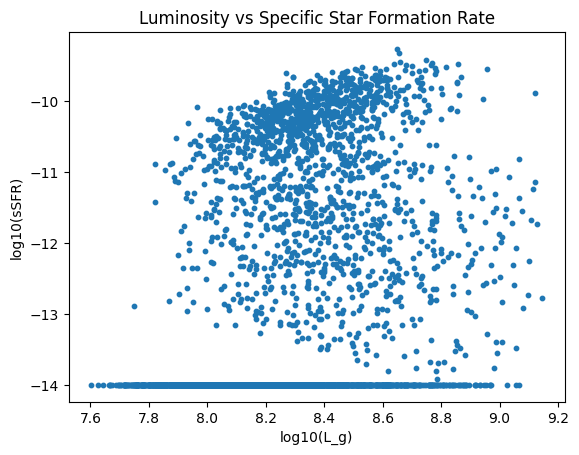

In [15]:
# Compute g - band luminosities
g1 = phot_s[i_final, 4]
g2 = phot_s[j_final, 4]

# Converting to relative luminosity
L1 = 10**(-0.4 * g1)
L2 = 10**(-0.4 * g2)

# Total pair luminosity
L_total = L1 + L2

# Log luminosities
logL1 = np.log10(L1)
logL2 = np.log10(L2)
logL_total = np.log10(L_total)

logL_all = np.concatenate([logL1, logL2])

plt.figure()
plt.scatter(logL_all, log_ssfr_all, s=10)
plt.xlabel("log10(L_g)")
plt.ylabel("log10(sSFR)")
plt.title("Luminosity vs Specific Star Formation Rate")
plt.show()


Again the floor at the bottom of the plot but we could remove it if we are only looking at star formation galaxies. Now Let's look at Color vs Luminosity plot.

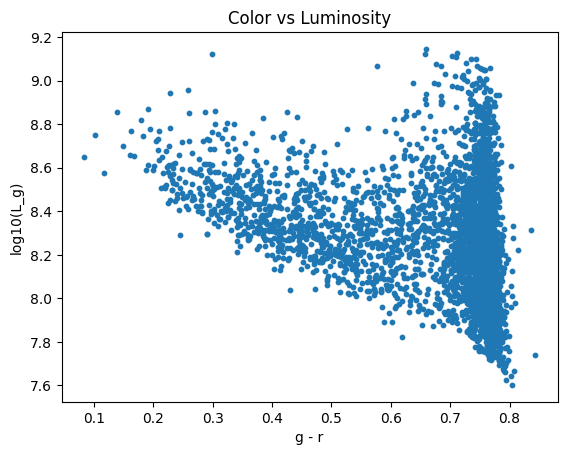

In [16]:
plt.figure()
plt.scatter(g_r_all, logL_all, s=10)
plt.xlabel("g - r")
plt.ylabel("log10(L_g)")
plt.title("Color vs Luminosity")
plt.show()


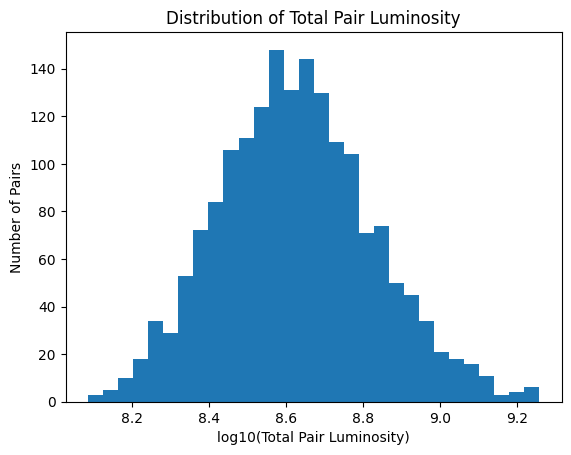

In [17]:
plt.figure()
plt.hist(logL_total, bins=30)
plt.xlabel("log10(Total Pair Luminosity)")
plt.ylabel("Number of Pairs")
plt.title("Distribution of Total Pair Luminosity")
plt.show()


Now lets do B-V Color histogram

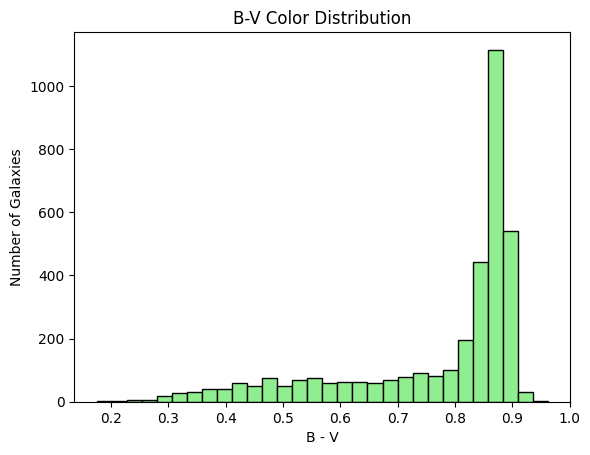

In [18]:
B_V_1 = phot_s[i_final, 1] - phot_s[i_final, 2]
B_V_2 = phot_s[j_final, 1] - phot_s[j_final, 2]

B_V_all = np.concatenate([B_V_1, B_V_2])

plt.figure()
plt.hist(B_V_all, bins=30, color='lightgreen', edgecolor='k')
plt.xlabel("B - V")
plt.ylabel("Number of Galaxies")
plt.title("B-V Color Distribution")
plt.show()


I believe we dont see bimodality because of our stellar mass filtering criteria. Perhaps at LG-analogue masses, most pair members are red/quenched. We found out that only 9% of pairs have both members blue (g-r < 0.65). This is rather interesting because the real MW and M31 are both relatively blue.

### Categorization of galaxies by their type (elliptical vs spiral) based on sSFR (Star Formation Rate (SFR) / Stellar mass (M*) ratio)

- Spiral Galaxies: High SFRs (Star Formation Rates), driven by gas-rich environments, providing fuel for ongoing stellar birth.
- Elliptical Galaxies: Extremely low SFRs. They are considered "dead" because they have used up or lost their gas.
- Milky Way forms approx 6–7 Msun/year, while Andromeda (M31) forms approx 0.4 Msun/year. / Source: Google AI (for now)
- That is, MW & M31 are both spiral galaxies.

Text(0.5, 1.0, 'sSFR_i vs sSFR_j: spiral-spiral top right corner')

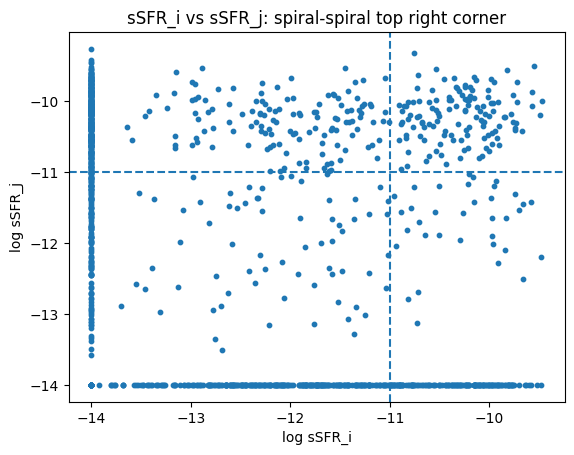

In [19]:
plt.scatter(log_ssfr1, log_ssfr2, s=10)
plt.axvline(-11, linestyle="--")
plt.axhline(-11, linestyle="--")
plt.xlabel("log sSFR_i")
plt.ylabel("log sSFR_j")
plt.title("sSFR_i vs sSFR_j: spiral-spiral top right corner")

# Double-checking the number of unique points. >> Some of the dots are on top of each.
#unique_points = len(np.unique(np.column_stack((log_sSFR_i, log_sSFR_j)), axis=0))
#print(unique_points)


- Many dots are at -14, which mean they have SFR = 0 and are totally dead.
- sSFR > -11 is spiral, and sSFR <= -11 is elliptical.
- So top-right corner = spiral-spiral, top-left and bottom-right = mixed, bottom-left = elliptical-elliptical

Text(0.5, 1.0, 'Density plot to show where most pairs lie')

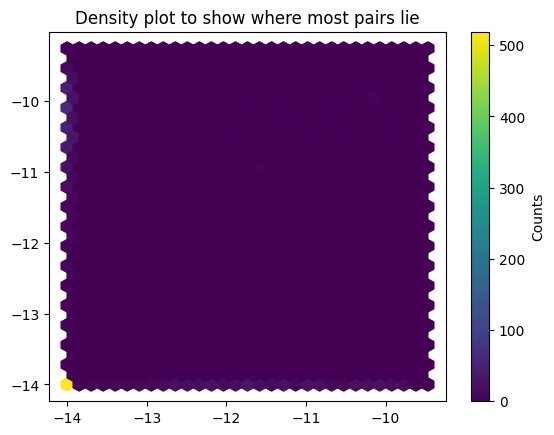

In [20]:
plt.hexbin(log_ssfr1, log_ssfr2, gridsize=30)
plt.colorbar(label="Counts")
plt.title("Density plot to show where most pairs lie")

Above: Density plot describes the dominance of subhalo pairs or galaxies with SFR = 0 (-16).

Text(0.5, 1.0, 'Number of various types of pairs')

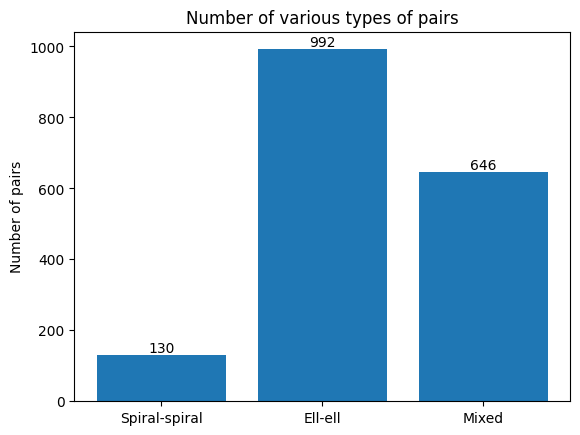

In [21]:
n_spiral_spiral = np.sum((log_ssfr1 > -11) & (log_ssfr2 > -11))
n_ell_ell = np.sum((log_ssfr1 <= -11) & (log_ssfr2 <= -11))
mixed = len(log_ssfr1) - n_spiral_spiral - n_ell_ell

bars = plt.bar(
    ["Spiral-spiral", "Ell-ell", "Mixed"],
    [n_spiral_spiral, n_ell_ell, mixed]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.ylabel("Number of pairs")
plt.title("Number of various types of pairs")

Above: The plot shows the pair types in bars.

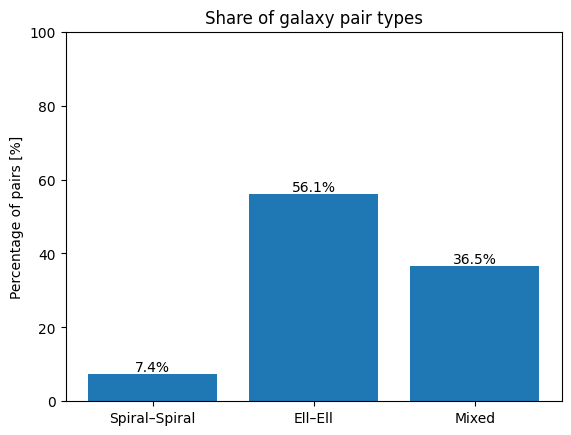

In [22]:
total = len(log_ssfr1)

spiral_pct = 100 * n_spiral_spiral / total
ell_pct = 100 * n_ell_ell / total
mixed_pct = 100 * mixed / total

bars = plt.bar(
    ["Spiral–Spiral", "Ell–Ell", "Mixed"],
    [spiral_pct, ell_pct, mixed_pct]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha='center',
        va='bottom'
    )

plt.ylabel("Percentage of pairs [%]")
plt.title("Share of galaxy pair types")
plt.ylim(0, 100)

plt.show()

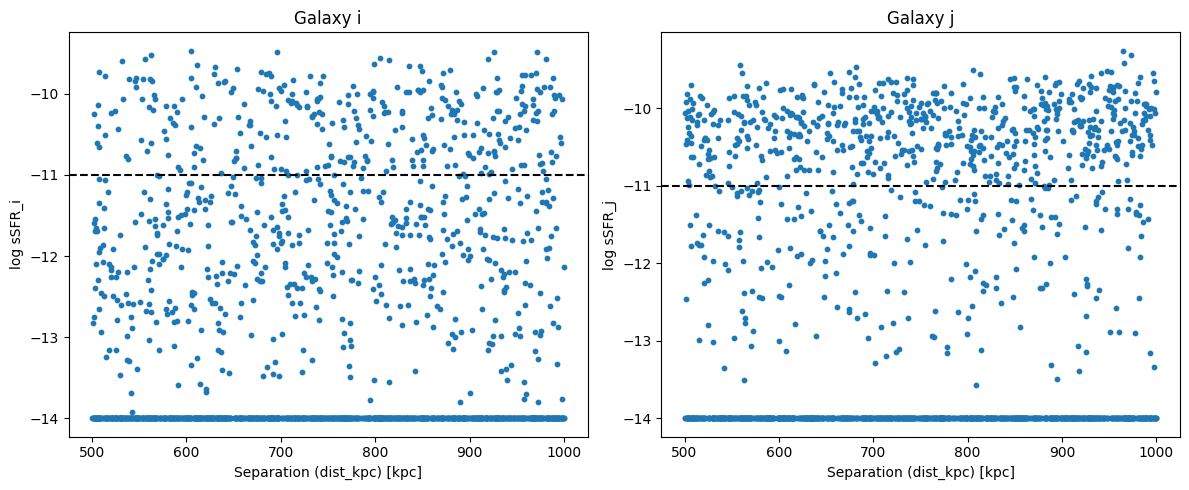

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Left: i
axes[0].scatter(dist_kpc_final, log_ssfr1, s=10) # Or should dist [ckpc/h] be used?
axes[0].set_xlabel("Separation (dist_kpc) [kpc]")
axes[0].set_ylabel("log sSFR_i")
axes[0].set_title("Galaxy i")
axes[0].axhline(-11, linestyle="--", color="k")

# Right: j
axes[1].scatter(dist_kpc_final, log_ssfr2, s=10)
axes[1].set_xlabel("Separation (dist_kpc) [kpc]")
axes[1].set_ylabel("log sSFR_j")
axes[1].set_title("Galaxy j")
axes[1].axhline(-11, linestyle="--", color="k")

plt.tight_layout()

Above: Scatter plot of separation vs. sSFR i & j.

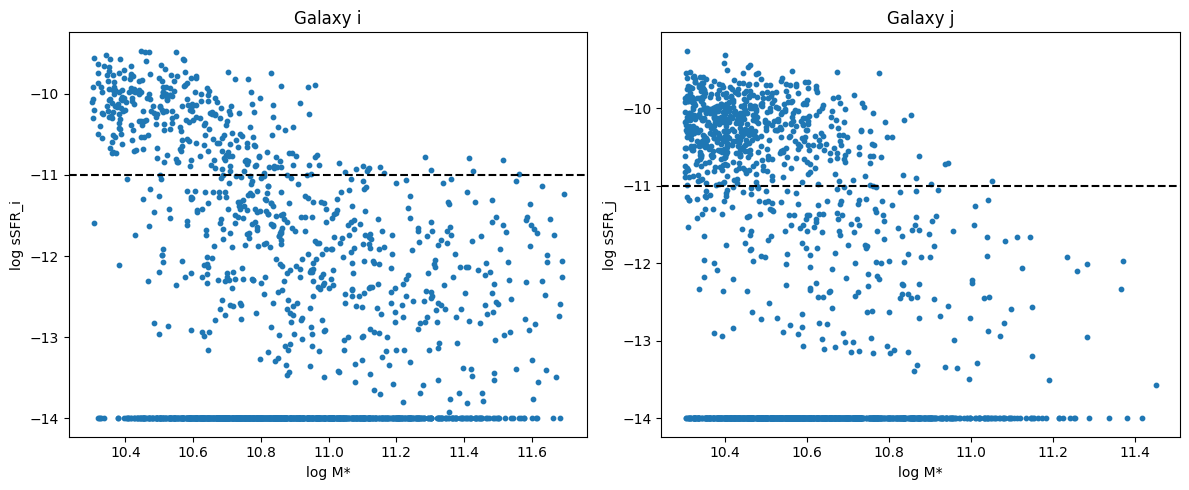

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Left: i
axes[0].scatter(np.log10(Mi_star),
    log_ssfr1, s=10)
axes[0].set_xlabel("log M*")
axes[0].set_ylabel("log sSFR_i")
axes[0].set_title("Galaxy i")
axes[0].axhline(-11, linestyle="--", color="k")

# Right: j
axes[1].scatter(np.log10(Mj_star),
    log_ssfr2, s=10)
axes[1].set_xlabel("log M*")
axes[1].set_ylabel("log sSFR_j")
axes[1].set_title("Galaxy j")
axes[1].axhline(-11, linestyle="--", color="k")

plt.tight_layout()

Above: Scatter plot of log(stellar mass) vs. sSFR on i & j. Elliptical galaxies could be expected to have a higher mass than spiral galaxies.

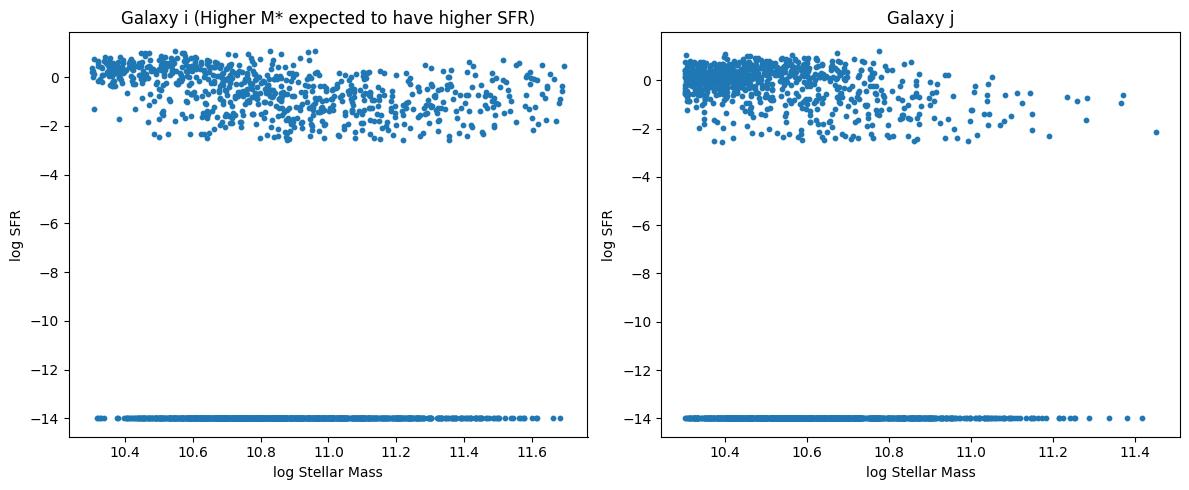

In [25]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- Galaxy i ---
axes[0].scatter(
    np.log10(Mi_star),
    np.log10(sfr_s[i_final] + 1e-14), # Add 1e-14, so that stars with SFR = 0 get a value.
    s=10
)
axes[0].set_xlabel("log Stellar Mass")
axes[0].set_ylabel("log SFR")
axes[0].set_title("Galaxy i (Higher M* expected to have higher SFR)")

# --- Galaxy j ---
axes[1].scatter(
    np.log10(Mj_star),
    np.log10(sfr_s[j_final] + 1e-14), # Add 1e-14, so that stars with SFR = 0 get a value.
    s=10
)
axes[1].set_xlabel("log Stellar Mass")
axes[1].set_ylabel("log SFR")
axes[1].set_title("Galaxy j")

plt.tight_layout()
plt.show()


Above: Scatter plot of stellar mass vs SFR. Higher M* is expected to have higher SFR. Note, however, that higher M* is expected to have lower sSFR.

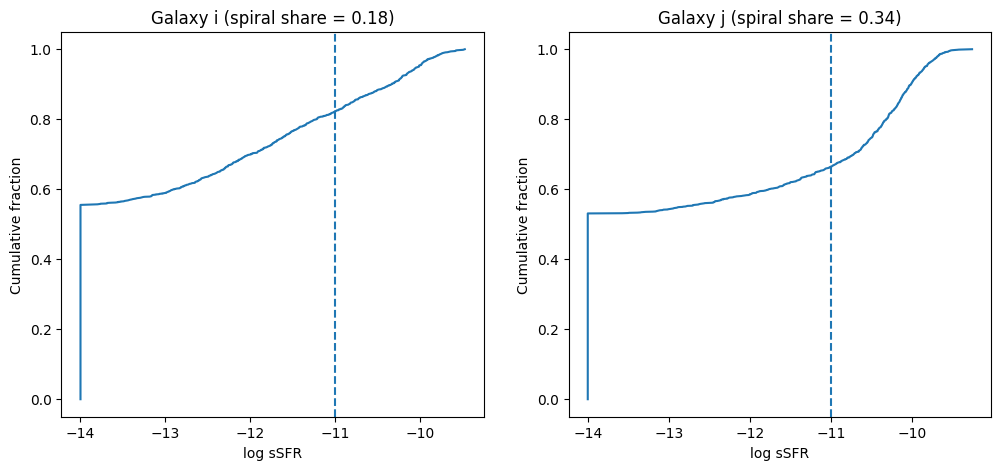

In [26]:
# Sort values for i
sorted_i = np.sort(log_ssfr1)
cdf_i = np.arange(len(sorted_i)) / len(sorted_i)
spiral_frac_i = np.mean(log_ssfr1 > -11) # Calculate the share of spiral galaxies out of total

# Sort values for j
sorted_j = np.sort(log_ssfr2)
cdf_j = np.arange(len(sorted_j)) / len(sorted_j)
spiral_frac_j = np.mean(log_ssfr2 > -11) # Calculate the share of sprial galaxies out of total

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Left panel: galaxy i
axes[0].plot(sorted_i, cdf_i)
axes[0].axvline(-11, linestyle="--")
axes[0].set_xlabel("log sSFR")
axes[0].set_ylabel("Cumulative fraction")
axes[0].set_title(f"Galaxy i (spiral share = {spiral_frac_i:.2f})") #"Galaxy i: Cumulative fraction of galaxies based on their log(sSFR)")

# Right panel: galaxy j
axes[1].plot(sorted_j, cdf_j)
axes[1].axvline(-11, linestyle="--")
axes[1].set_xlabel("log sSFR")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title(f"Galaxy j (spiral share = {spiral_frac_j:.2f})")

plt.show()

Above: Cumulative pairs based on sSFR.

In [27]:
# Comparison

spiral_pairs = (log_ssfr1 > -11) & (log_ssfr2 > -11)
ell_pairs = (log_ssfr1 <= -11) & (log_ssfr2 <= -11)
#print(f"spiral-spiral: {spiral_pairs}")
#print(f"ell-ell: {ell_pairs}")

blue_1 = g_r_1 < 0.65
blue_2 = g_r_2 < 0.65
#print(g_r_2)

blue_pairs = np.logical_and(blue_1, blue_2)
num_blue_pairs = np.sum(blue_pairs)
total_pairs = len(i_final)
print(f"Number of pairs with both members blue: {num_blue_pairs} / {total_pairs}")
print(f"Fraction of pairs with both members blue: {num_blue_pairs / total_pairs:.2f}")

print(f"Galaxy i: {blue_1.sum()} blue (spiral-like) out of {len(blue_1)} total")
print(f"Galaxy j: {blue_2.sum()} blue (spiral-like) out of {len(blue_2)} total")

#print(blue_pairs)

Number of pairs with both members blue: 167 / 1768
Fraction of pairs with both members blue: 0.09
Galaxy i: 373 blue (spiral-like) out of 1768 total
Galaxy j: 655 blue (spiral-like) out of 1768 total


In [28]:
#Pairs that are both blue and spiral
both_blue_and_spiral = blue_pairs & spiral_pairs
print("Pairs classified both blue and spiral:", both_blue_and_spiral.sum())

# Blue and not spiral
blue_not_spiral = blue_pairs & ~spiral_pairs
print("Blue but not spiral:", blue_not_spiral.sum())

# Spiral and not blue
spiral_not_blue = spiral_pairs & ~blue_pairs
print("Spiral but not blue:", spiral_not_blue.sum())

Pairs classified both blue and spiral: 127
Blue but not spiral: 40
Spiral but not blue: 3


In [29]:
TP = np.sum(blue_pairs & spiral_pairs)          # both say "yes"
TN = np.sum(~blue_pairs & ~spiral_pairs)        # both say "no"
FP = np.sum(blue_pairs & ~spiral_pairs)         # blue only
FN = np.sum(~blue_pairs & spiral_pairs)         # spiral only

print("Both blue & spiral:", TP)
print("Neither:", TN)
print("Blue only:", FP)
print("Spiral only:", FN)

Both blue & spiral: 127
Neither: 1598
Blue only: 40
Spiral only: 3


Text(0.5, 1.0, 'Number of various types of pairs')

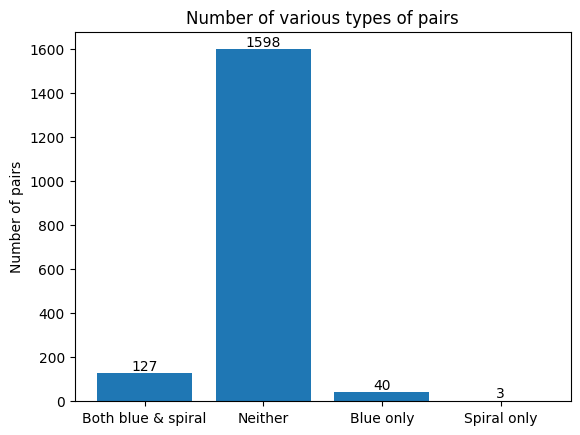

In [30]:
bars = plt.bar(
    ["Both blue & spiral", "Neither", "Blue only", "Spiral only"],
    [TP, TN, FP, FN]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.ylabel("Number of pairs")
plt.title("Number of various types of pairs")

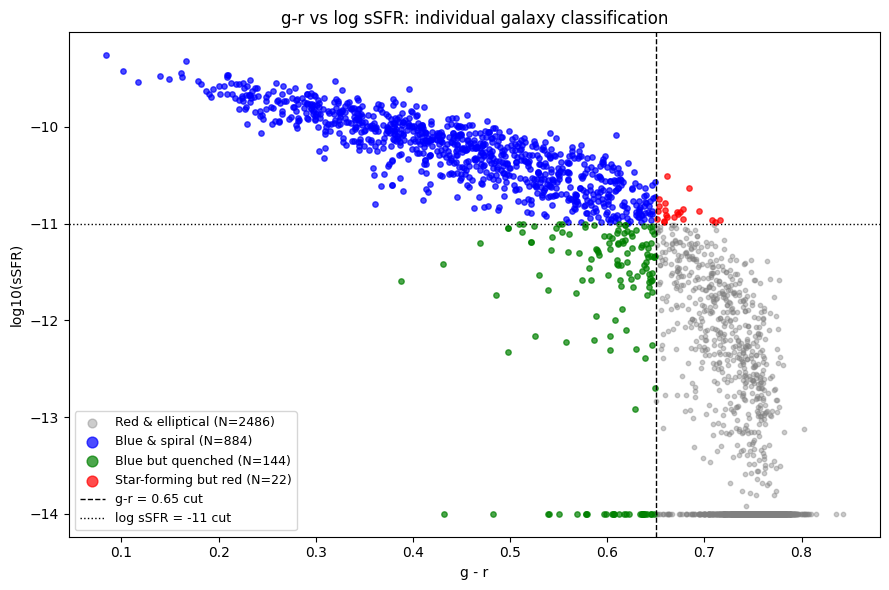

Total galaxies: 3536
Blue & spiral:        884 (25.0%)
Red & elliptical:     2486 (70.3%)
Blue but quenched:    144 (4.1%)
Star-forming but red: 22 (0.6%)


In [31]:
# Colour by individual galaxy classification 
g_r_all_pairs = np.concatenate([g_r_1, g_r_2])
log_ssfr_all_pairs = np.concatenate([log_ssfr1, log_ssfr2])

# Individual galaxy masks
is_blue_all = g_r_all_pairs < 0.65
is_spiral_all = log_ssfr_all_pairs > -11

# Four categories at galaxy level
TP_gal = is_blue_all & is_spiral_all          # blue AND spiral
TN_gal = ~is_blue_all & ~is_spiral_all        # red AND elliptical
FP_gal = is_blue_all & ~is_spiral_all         # blue but quenched
FN_gal = ~is_blue_all & is_spiral_all         # red but star-forming

plt.figure(figsize=(9, 6))

plt.scatter(g_r_all_pairs[TN_gal], log_ssfr_all_pairs[TN_gal],
            s=10, alpha=0.4, color='gray', label=f'Red & elliptical (N={TN_gal.sum()})')
plt.scatter(g_r_all_pairs[TP_gal], log_ssfr_all_pairs[TP_gal],
            s=15, alpha=0.7, color='blue', label=f'Blue & spiral (N={TP_gal.sum()})')
plt.scatter(g_r_all_pairs[FP_gal], log_ssfr_all_pairs[FP_gal],
            s=15, alpha=0.7, color='green', label=f'Blue but quenched (N={FP_gal.sum()})')
plt.scatter(g_r_all_pairs[FN_gal], log_ssfr_all_pairs[FN_gal],
            s=15, alpha=0.7, color='red', label=f'Star-forming but red (N={FN_gal.sum()})')

plt.axvline(0.65, color='black', linestyle='--', linewidth=1, label='g-r = 0.65 cut')
plt.axhline(-11, color='black', linestyle=':', linewidth=1, label='log sSFR = -11 cut')

plt.xlabel('g - r')
plt.ylabel('log10(sSFR)')
plt.title('g-r vs log sSFR: individual galaxy classification')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

print(f"Total galaxies: {len(g_r_all_pairs)}")
print(f"Blue & spiral:        {TP_gal.sum()} ({100*TP_gal.sum()/len(g_r_all_pairs):.1f}%)")
print(f"Red & elliptical:     {TN_gal.sum()} ({100*TN_gal.sum()/len(g_r_all_pairs):.1f}%)")
print(f"Blue but quenched:    {FP_gal.sum()} ({100*FP_gal.sum()/len(g_r_all_pairs):.1f}%)")
print(f"Star-forming but red: {FN_gal.sum()} ({100*FN_gal.sum()/len(g_r_all_pairs):.1f}%)")

The main finding from the above plot is both methods g-r color and sSFR are consistent. 884 out of 3536 pairs are both blue and spiral. The vast majority of galaxies in LG-analogue pairs are red and elliptical (70%), consistent with the finding that only 9% of pairs have both members blue. The real Local Group, where both MW and M31 are blue spiral galaxies, represents 7% of kinematically-selected LG-analogue pairs in this sample

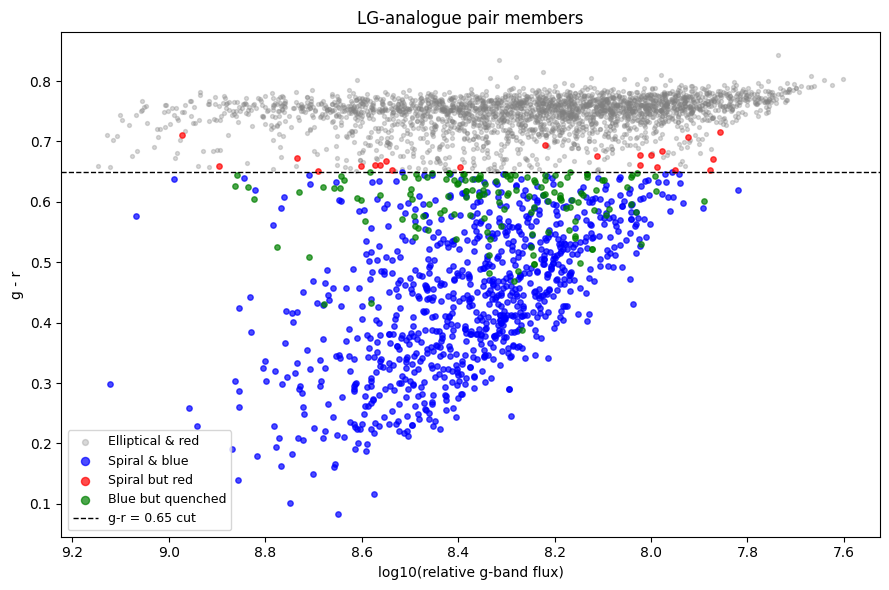

In [32]:
fig, ax = plt.subplots(figsize=(9, 6))

# All galaxies in pairs
all_g_r = np.concatenate([g_r_1, g_r_2])
all_logL = np.concatenate([logL1, logL2])
all_log_ssfr = np.concatenate([log_ssfr1, log_ssfr2])

# Classification masks at galaxy level
is_spiral = all_log_ssfr > -11
is_blue = all_g_r < 0.65

ax.scatter(all_logL[~is_spiral & ~is_blue], all_g_r[~is_spiral & ~is_blue],
           s=8, alpha=0.3, color='gray', label='Elliptical & red')
ax.scatter(all_logL[is_spiral & is_blue], all_g_r[is_spiral & is_blue],
           s=15, alpha=0.7, color='blue', label='Spiral & blue')
ax.scatter(all_logL[is_spiral & ~is_blue], all_g_r[is_spiral & ~is_blue],
           s=15, alpha=0.7, color='red', label='Spiral but red')
ax.scatter(all_logL[~is_spiral & is_blue], all_g_r[~is_spiral & is_blue],
           s=15, alpha=0.7, color='green', label='Blue but quenched')

# Classifier boundary
ax.axhline(0.65, color='black', linestyle='--', linewidth=1, label='g-r = 0.65 cut')

ax.set_xlabel('log10(relative g-band flux)')
ax.set_ylabel('g - r')
ax.set_title('LG-analogue pair members')
ax.legend(markerscale=1.5, fontsize=9)
ax.invert_xaxis()  
plt.tight_layout()
plt.show()

The plot above is about the individual pair members rather taking into account both. We can see in the plot that majority is elliptical and red followed by spiral and blue. 

In [33]:
# Individual blue fractions
blue_i_frac = np.mean(g_r_1 < 0.65)
blue_j_frac = np.mean(g_r_2 < 0.65)

print(f"Fraction of i galaxies that are blue: {blue_i_frac:.2f}")
print(f"Fraction of j galaxies that are blue: {blue_j_frac:.2f}")
print(f"Expected both-blue if independent: {blue_i_frac * blue_j_frac:.2f}")
print(f"Actual both-blue fraction: {fraction_both_blue:.2f}")

frac_i_more_massive = np.mean(mstar_s[i_final] > mstar_s[j_final])
print(f"\nFraction of pairs where i is more massive than j: {frac_i_more_massive:.2f}")


Fraction of i galaxies that are blue: 0.21
Fraction of j galaxies that are blue: 0.37
Expected both-blue if independent: 0.08
Actual both-blue fraction: 0.09

Fraction of pairs where i is more massive than j: 0.84


j galaxies might be more bluer because of how our selection criteria works. From what I understand it picks the centrals and largest satellites so the j member should be of lower mass compared to the centrals so possibly less quenched and more bluer. Confirmed from the above fraction as well i is more massive than j for 84% of the pairs.

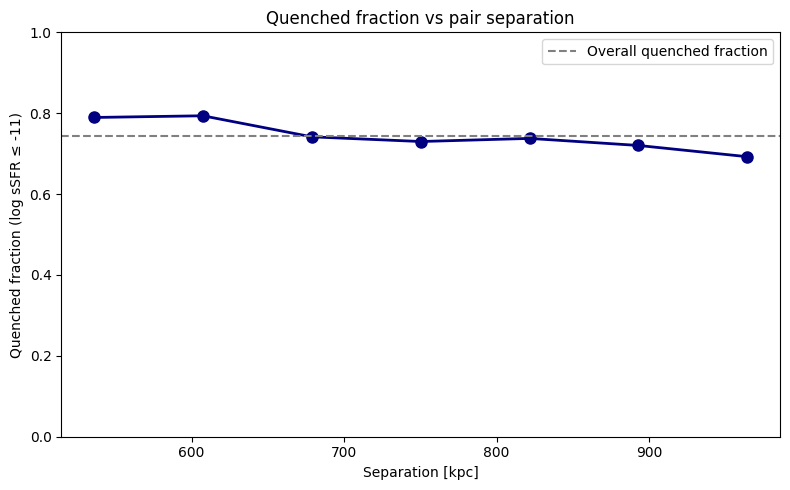

In [34]:
# Quenched fraction vs separation
sep_bins = np.linspace(dist_kpc_final.min(), dist_kpc_final.max(), 8)
bin_centers = 0.5 * (sep_bins[:-1] + sep_bins[1:])

quenched_frac = []
for s, e in zip(sep_bins[:-1], sep_bins[1:]):
    in_bin = (dist_kpc_final >= s) & (dist_kpc_final < e)
    if in_bin.sum() == 0:
        quenched_frac.append(np.nan)
        continue
    # Galaxy i and j in this bin
    ssfr_i_bin = log_ssfr1[in_bin]
    ssfr_j_bin = log_ssfr2[in_bin]
    all_ssfr_bin = np.concatenate([ssfr_i_bin, ssfr_j_bin])
    quenched_frac.append(np.mean(all_ssfr_bin <= -11))

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, quenched_frac, 'o-', color='navy', linewidth=2, markersize=8)
plt.xlabel('Separation [kpc]')
plt.ylabel('Quenched fraction (log sSFR ≤ -11)')
plt.title('Quenched fraction vs pair separation')
plt.ylim(0, 1)
plt.axhline(np.mean(np.concatenate([log_ssfr1, log_ssfr2]) <= -11),
            color='gray', linestyle='--', label='Overall quenched fraction')
plt.legend()
plt.tight_layout()
plt.show()

Pair seperation seems to have no effect on the quenched fraction. Now we look at kinematics of pair types.

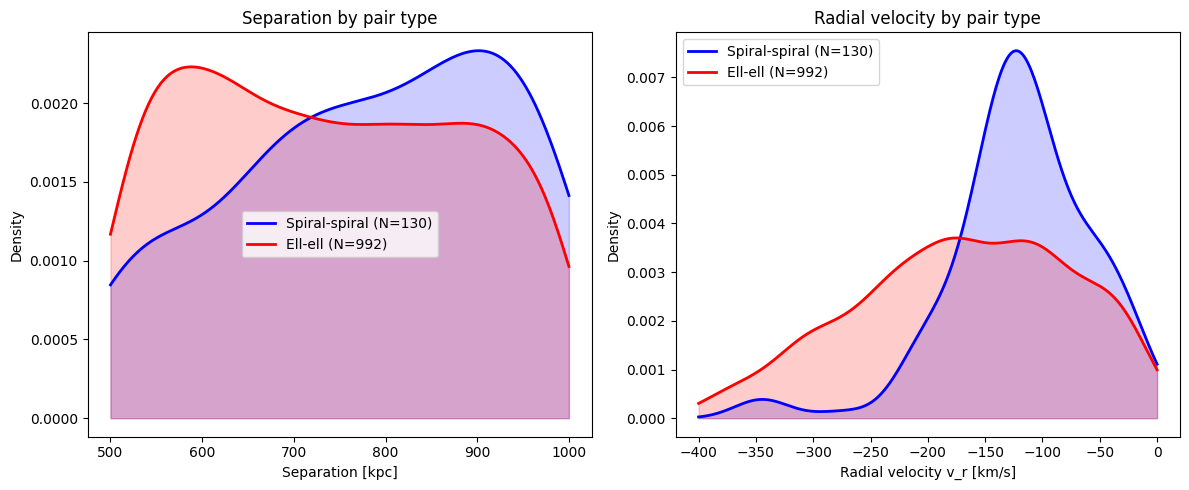

Spiral-spiral median separation: 793.1 kpc
Ell-ell median separation: 732.1 kpc
Spiral-spiral median v_r: -116.7 km/s
Ell-ell median v_r: -166.8 km/s


In [35]:
from scipy.stats import gaussian_kde

# Kinematics split by pair type
spiral_spiral = (log_ssfr1 > -11) & (log_ssfr2 > -11)
ell_ell = (log_ssfr1 <= -11) & (log_ssfr2 <= -11)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Separation
sep_range = np.linspace(500, 1000, 300)
kde_ss_sep = gaussian_kde(dist_kpc_final[spiral_spiral])
kde_ee_sep = gaussian_kde(dist_kpc_final[ell_ell])

axes[0].plot(sep_range, kde_ss_sep(sep_range), color='blue', linewidth=2, label=f'Spiral-spiral (N={spiral_spiral.sum()})')
axes[0].plot(sep_range, kde_ee_sep(sep_range), color='red', linewidth=2, label=f'Ell-ell (N={ell_ell.sum()})')
axes[0].fill_between(sep_range, kde_ss_sep(sep_range), alpha=0.2, color='blue')
axes[0].fill_between(sep_range, kde_ee_sep(sep_range), alpha=0.2, color='red')
axes[0].set_xlabel('Separation [kpc]')
axes[0].set_ylabel('Density')
axes[0].set_title('Separation by pair type')
axes[0].legend()

# Radial velocity
vr_range = np.linspace(-400, 0, 300)
kde_ss_vr = gaussian_kde(v_r_final[spiral_spiral])
kde_ee_vr = gaussian_kde(v_r_final[ell_ell])

axes[1].plot(vr_range, kde_ss_vr(vr_range), color='blue', linewidth=2, label=f'Spiral-spiral (N={spiral_spiral.sum()})')
axes[1].plot(vr_range, kde_ee_vr(vr_range), color='red', linewidth=2, label=f'Ell-ell (N={ell_ell.sum()})')
axes[1].fill_between(vr_range, kde_ss_vr(vr_range), alpha=0.2, color='blue')
axes[1].fill_between(vr_range, kde_ee_vr(vr_range), alpha=0.2, color='red')
axes[1].set_xlabel('Radial velocity v_r [km/s]')
axes[1].set_ylabel('Density')
axes[1].set_title('Radial velocity by pair type')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Spiral-spiral median separation: {np.median(dist_kpc_final[spiral_spiral]):.1f} kpc")
print(f"Ell-ell median separation: {np.median(dist_kpc_final[ell_ell]):.1f} kpc")
print(f"Spiral-spiral median v_r: {np.median(v_r_final[spiral_spiral]):.1f} km/s")
print(f"Ell-ell median v_r: {np.median(v_r_final[ell_ell]):.1f} km/s")

The LG has value of radial velocity = -110 km/s (Google Ai). Interestingly spiral-spiral plot also seems to peak around -120 which shows that the LG-like spiral-spiral pairs also share the same velocities as well as similar morphology.